In [166]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import sys
sys.path.append("../src")

import warnings
warnings.filterwarnings("ignore")

from Config.config import PATHS
from Utils.indices import AlternationIndex
from Utils.utils import GetMeasurements
from Utils.bar_utils import BarRenderer

In [167]:
path_to_data = PATHS['human_data'] / 'multi-player.csv'
data = pd.read_csv(path_to_data)
data['model'] = data.apply(lambda row: f"{row['num_players']}-{row['threshold']:.2f}-{row['group']}", axis=1)


In [168]:
gm = GetMeasurements(
    data=data, 
    measures=[
        'bounded_efficiency', 'entropy',
        'inequality', 'conditional_entropy', 'conditional_entropy_2nd_order', 'min_entropy'
    ],
    T=20
)
gm.columns.append('session')
gm.columns.append('approx_threshold')
print(gm.columns)
df = gm.get_measurements()
df['model'] = df.apply(lambda row: f"{row['num_players']}-{row['threshold']:.2f}-{row['group']}", axis=1)
df.head(2)

['model', 'treatment', 'threshold', 'num_players', 'group', 'session', 'approx_threshold']


,model,treatment,threshold,num_players,group,session,approx_threshold,bounded_efficiency,entropy,inequality,conditional_entropy,conditional_entropy_2nd_order,min_entropy
0,11-0.27-13,upwards,0.272727,11,13,1,0.25,-0.793651,0.403457,0.140236,0.009091,0.0,0.0
1,11-0.45-13,upwards,0.454545,11,13,2,0.50,-0.964286,0.403457,0.197803,0.009091,0.0,0.0


In [169]:
ai = AlternationIndex.from_file(priority='mlp')
df['predicted_class'] = ai.classify(df)

In [170]:
df_best = df[df['bounded_efficiency'] > 0.67]
df_best = df_best[df_best['threshold'] < 1]

# df_best['model'] = df_best.apply(lambda row: f"{row['model']}-{row['num_players']}-{row['threshold']:.2f}", axis=1)
df_best.sort_values(by=['bounded_efficiency', 'num_players'], ascending=False, inplace=True)
print('Num. of best sessions:', len(df_best))


Num. of best sessions: 18


<StringArray>
[        '4-0.25-25',         '3-0.67-24', '2-0.50-Grupo-0001',
 '2-0.50-Grupo-0005', '2-0.50-Grupo-0006', '2-0.50-Grupo-0011',
 '2-0.50-Grupo-0014', '2-0.50-Grupo-0021',         '4-0.75-15',
 '2-0.50-Grupo-0009',         '3-0.33-30', '2-0.50-Grupo-0015',
 '2-0.50-Grupo-0013',         '4-0.75-27', '2-0.50-Grupo-0003',
 '2-0.50-Grupo-0008', '2-0.50-Grupo-0012',         '5-0.80-14']
Length: 18, dtype: str
['4-0.25-25', '3-0.67-24', '2-0.50-Grupo-0006', '2-0.50-Grupo-0021', '4-0.75-15', '3-0.33-30', '4-0.75-27', '5-0.80-14']


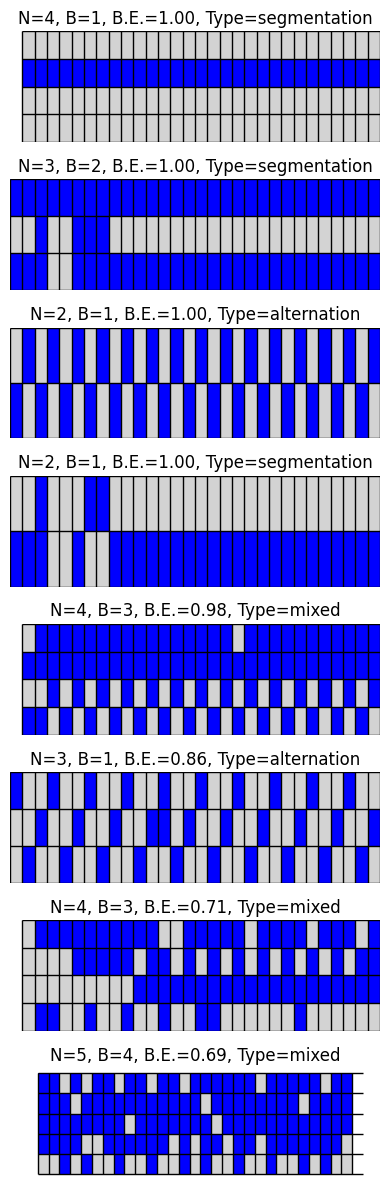

In [173]:
groups = df_best['model'].unique()
# keep_groups_idx = [
#     4, 3, 7, 8, 20, 16, 21, 5, 18, 14, 19, # 22
# ]
# groups = np.array(df_best['model'].unique())[keep_groups_idx].tolist()
print(groups)
excluded_groups = [
    '2-0.50-Grupo-0001', 
    '2-0.50-Grupo-0003', 
    '2-0.50-Grupo-0005', 
    '2-0.50-Grupo-0008', 
    '2-0.50-Grupo-0009', 
    '2-0.50-Grupo-0011', 
    '2-0.50-Grupo-0012', 
    '2-0.50-Grupo-0013', 
    '2-0.50-Grupo-0014',
    '2-0.50-Grupo-0015',
]
groups = [group for group in groups if group not in excluded_groups]
print(groups)
categories = [
    'alternation', 'alternation', 'segmentation',
    'alternation', 'mixed', 'segmentation',
    'alternation', 'mixed', 'segmentation',
    'mixed', 'mixed', # 'mixed'
]

fig, axes = plt.subplots(
    len(groups), 1, 
    figsize=(4, 12),
    tight_layout=True
)

for i, group in enumerate(groups):
    df_aux = df_best[df_best['model'] == group]
    df_aux_aux = data[data['model'] == group]
    threshold = df_aux['threshold'].unique()[0]
    BE = df_aux['bounded_efficiency'].unique()[0]
    N = df_aux_aux['num_players'].values[0]
    B = int(df_aux_aux['threshold'].values[0] * N)
    classification = df_aux['predicted_class'].values[0]
    # classification = categories[i]
    # classification = i
    # classification = df_aux['group'].values[0]
    bar_renderer = BarRenderer(data=df_aux_aux)
    bar_renderer.render(
        ax=axes[i],
        title=f"N={N}, B={B}, B.E.={BE:.2f}, Type={classification}",
        num_rounds=30
    )


In [174]:
fig.savefig(PATHS['exploratory_figures'] / 'Fig5.png', dpi=300, bbox_inches='tight')